In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import os

metadata = pd.read_csv('C:/Users/thott/Downloads/Voiceset/en/other.tsv', sep="\t")

print(metadata.head())

print(metadata.columns)

                                           client_id  \
0  0b58339ed9062b97e92c9cc6a5d46f8a517bdd8f5d6b83...   
1  29b8505586cd43382cd695da6b943f401104be710a5b60...   
2  29b8505586cd43382cd695da6b943f401104be710a5b60...   
3  29b8505586cd43382cd695da6b943f401104be710a5b60...   
4  29b8505586cd43382cd695da6b943f401104be710a5b60...   

                           path  \
0  common_voice_en_41236242.mp3   
1  common_voice_en_41247165.mp3   
2  common_voice_en_41247167.mp3   
3  common_voice_en_41247169.mp3   
4  common_voice_en_41247171.mp3   

                                         sentence_id  \
0  f1662e17d5758c78c88f7ccd83a54d93c2bfbbfd0cb6ea...   
1  f15888200849728aa175d0df98e75fa5e253cd25fe9398...   
2  f149221736fee116e91b410d96bb421bfb94b3a023fb34...   
3  f169c2a91589d2247278336f55434318cc916f4deb08a4...   
4  f1570bceb193650b19077436c3ef52f7dc63268f4d0fe7...   

                                            sentence sentence_domain  \
0  She studied theatre and spent time as a 

In [2]:
from pydub import AudioSegment
import os

input_directory = "C:/Users/thott/Downloads/Voiceset/en/clips"
output_directory = "C:/Users/thott/Downloads/Voiceset/en/clips_wav"

if not os.path.exists(output_directory):
    os.makedirs(output_directory)

def convert_mp3_to_wav(mp3_path, wav_path):
    try:
        audio = AudioSegment.from_mp3(mp3_path)
        audio.export(wav_path, format="wav")
        print(f"Successfully converted: {mp3_path} to {wav_path}")
    except Exception as e:
        print(f"Error converting {mp3_path}: {e}")

for filename in os.listdir(input_directory):
    if filename.endswith(".mp3"):
        mp3_path = os.path.join(input_directory, filename).replace("\\", "/")
        wav_filename = filename.replace(".mp3", ".wav")
        wav_path = os.path.join(output_directory, wav_filename).replace("\\", "/")
        
        convert_mp3_to_wav(mp3_path, wav_path)

In [3]:
import librosa
import soundfile as sf
import os

def resample_audio(audio_file, target_sample_rate=16000, output_directory="C:/Users/thott/Downloads/Voiceset/en/clips_resampled"):
    try:
        y, sr = librosa.load(audio_file, sr=None)
        
        y_resampled = librosa.resample(y, orig_sr=sr, target_sr=target_sample_rate)
        
        os.makedirs(output_directory, exist_ok=True)
        
        output_file = os.path.join(output_directory, os.path.basename(audio_file).replace(".wav", "_resampled.wav"))
        sf.write(output_file, y_resampled, target_sample_rate)
        print(f"Successfully resampled {audio_file} to {output_file}.")
        
    except Exception as e:
        print(f"Error resampling {audio_file}: {e}")

audio_directory = "C:/Users/thott/Downloads/Voiceset/en/clips_wav"
resampled_directory = "C:/Users/thott/Downloads/Voiceset/en/clips_resampled"

for filename in os.listdir(audio_directory):
    if filename.endswith(".wav"):
        audio_file = os.path.join(audio_directory, filename)
        resample_audio(audio_file, output_directory=resampled_directory)

In [4]:
import torch
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
import torchaudio
import os

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-large-960h")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-large-960h")

def transcribe_audio(audio_path):
    try:
        audio_input, sample_rate = torchaudio.load(audio_path)
        if audio_input.shape[0] > 1:
            audio_input = torch.mean(audio_input, dim=0, keepdim=True)
        if sample_rate != 16000:
            transform = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000)
            audio_input = transform(audio_input)
        audio_input = audio_input.squeeze(0)
        inputs = processor(audio_input, return_tensors="pt", sampling_rate=16000)
        with torch.no_grad():
            logits = model(inputs.input_values).logits
        predicted_ids = torch.argmax(logits, dim=-1)
        transcription = processor.batch_decode(predicted_ids)[0]
        
        return transcription

    except Exception as e:
        print(f"Error transcribing {audio_path}: {e}")
        return None
audio_directory = "C:/Users/thott/Downloads/Voiceset/en/clips_resampled"
transcriptions = {}
for filename in os.listdir(audio_directory):
    if filename.endswith(".wav"):
        audio_path = os.path.join(audio_directory, filename)
        transcription = transcribe_audio(audio_path)
        if transcription:
            transcriptions[filename] = transcription
            print(f"Transcription for {filename}: {transcription}")

In [5]:
transcriptions = {}

audio_directory = "C:/Users/thott/Downloads/Voiceset/en/clips_resampled"

for index, row in metadata.iterrows():
    filename = os.path.join(audio_directory, row['path'])
    ground_truth = row['sentence']

    if filename in transcriptions:
        hypothesis = transcriptions[filename]
        accent_group = row['accents']

In [6]:
import pandas as pd

pred_df = pd.read_csv("C:/Users/thott/Downloads/Voiceset/en/transcriptions.tsv", sep='\t')
pred_df.columns = ["filename", "predicted"]

gt_df = pd.read_csv("C:/Users/thott/Downloads/Voiceset/en/other.tsv", sep='\t')
gt_df = gt_df[["path", "sentence", "accents"]]
gt_df.columns = ["filename", "ground_truth", "accent"]

gt_df["filename"] = gt_df["filename"].str.replace(".mp3", "_resampled.wav", regex=False)

In [7]:
merged_df = pd.merge(pred_df, gt_df, on="filename")
print(f"Merged rows: {len(merged_df)}")
print(merged_df.head())

Merged rows: 18162
                                 filename  \
0  common_voice_en_41236242_resampled.wav   
1  common_voice_en_41247165_resampled.wav   
2  common_voice_en_41247167_resampled.wav   
3  common_voice_en_41247169_resampled.wav   
4  common_voice_en_41247171_resampled.wav   

                                           predicted  \
0  HE STUDIED THEATRE AND SPENT TIME AS A DIRECTI...   
1                     STAL WAS AT THE FISTIN ANDTASK   
2  TES PAPA SUPPOD OR KRAMKAR HOTWARE POTTED THEI...   
3  HE WAS PROTEST FOR HONCOCK BUSINESS MAN MISTER...   
4     HOWEVER BESIDWAS THE PATH DAYOS THING TOWAS WI   

                                        ground_truth            accent  
0  She studied theatre and spent time as a direct...               NaN  
1               Steve will set the Fist team a task.  Scottish English  
2  This provides support for graphical hardware, ...  Scottish English  
3  He was purchased for Hong Kong businessman Mr ...  Scottish English  
4  Howev

In [8]:
if 'accent' in merged_df.columns:
    merged_df = merged_df.drop(columns=['accent'])

def format_sentence(text):
    text = str(text).strip().lower()
    return text.capitalize()

merged_df["predicted"] = merged_df["predicted"].apply(format_sentence)
merged_df["ground_truth"] = merged_df["ground_truth"].apply(format_sentence)

print(merged_df.head())

                                 filename  \
0  common_voice_en_41236242_resampled.wav   
1  common_voice_en_41247165_resampled.wav   
2  common_voice_en_41247167_resampled.wav   
3  common_voice_en_41247169_resampled.wav   
4  common_voice_en_41247171_resampled.wav   

                                           predicted  \
0  He studied theatre and spent time as a directi...   
1                     Stal was at the fistin andtask   
2  Tes papa suppod or kramkar hotware potted thei...   
3  He was protest for honcock business man mister...   
4     However besidwas the path dayos thing towas wi   

                                        ground_truth  
0  She studied theatre and spent time as a direct...  
1               Steve will set the fist team a task.  
2  This provides support for graphical hardware, ...  
3  He was purchased for hong kong businessman mr ...  
4  However, with time his sympathies leaned towar...  


In [9]:
merged_df.to_csv("cleaned_transcriptions.tsv", sep='\t', index=False)

In [10]:
from jiwer import wer

overall_wer = wer(merged_df["ground_truth"].tolist(), merged_df["predicted"].tolist())
print(f"🔤 Overall WER: {overall_wer:.3f}")

🔤 Overall WER: 0.572


In [14]:
from fairlearn.metrics import MetricFrame
import numpy as np

def mean_wer(y_true, y_pred):
    return np.mean(y_pred)

metric_frame = MetricFrame(
    metrics=mean_wer,
    y_true=np.zeros(len(merged_df)),
    y_pred=merged_df["wer"],
    sensitive_features=merged_df["accent"]
)

print("📊 Fairness Evaluation (Average WER by Accent):")
print(metric_frame.by_group)
print(f"\n🎯 Overall Mean WER: {metric_frame.overall:.3f}")

📊 Fairness Evaluation (Average WER by Accent):
accent
Australian English                                                        0.384317
Brazilian                                                                 0.334732
British with slightly Brazilian accent                                    0.349798
British with slightly Brazilian accent,British and slightly Brazilian     0.201854
Californian Accent                                                        0.150880
                                                                            ...   
Ze German Akzent with North American influence                            0.319204
chicago italian                                                           0.393975
eastafrican                                                               0.268015
geordie ,England Northern                                                 0.301104
international                                                             0.382292
Name: mean_wer, Length: 67, dtype

In [15]:
group_wers = metric_frame.by_group

max_disparity = group_wers.max() - group_wers.min()
print(f"📉 Max WER Disparity Across Accents: {max_disparity:.3f}")

worst_to_best_ratio = group_wers.max() / group_wers.min()
print(f"⚖️  WER Ratio (Worst / Best): {worst_to_best_ratio:.2f}")

📉 Max WER Disparity Across Accents: 1.684
⚖️  WER Ratio (Worst / Best): 12.16


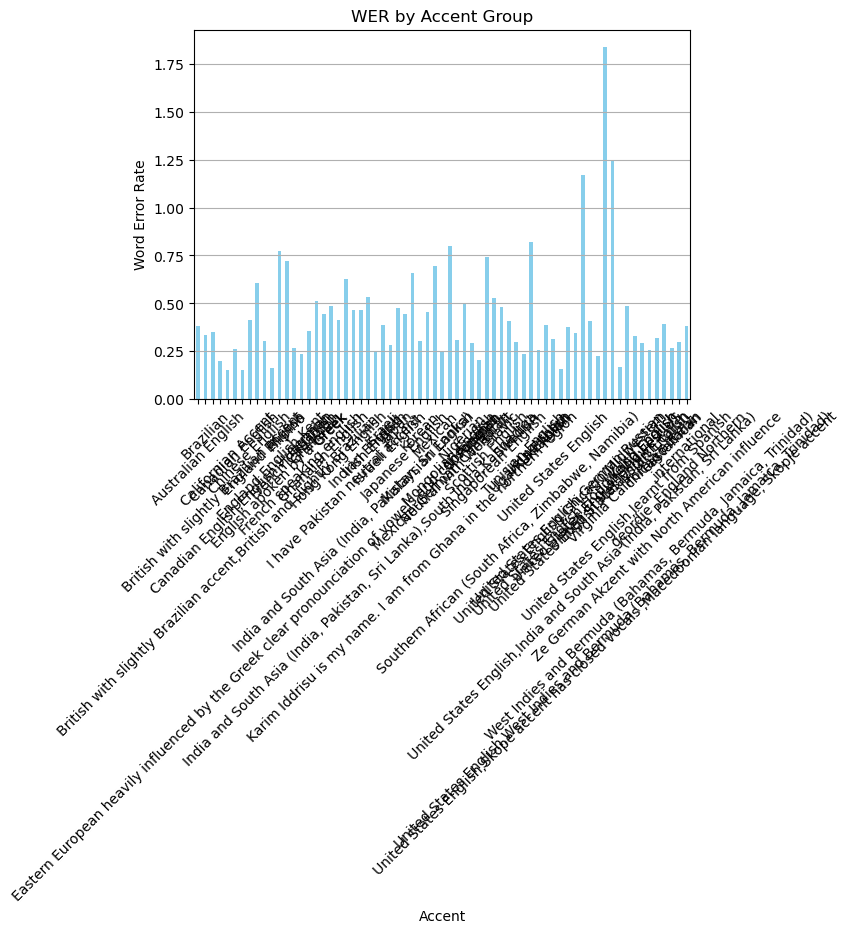

In [16]:
import matplotlib.pyplot as plt

group_wers.plot(kind='bar', color='skyblue')
plt.title('WER by Accent Group')
plt.ylabel('Word Error Rate')
plt.xlabel('Accent')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

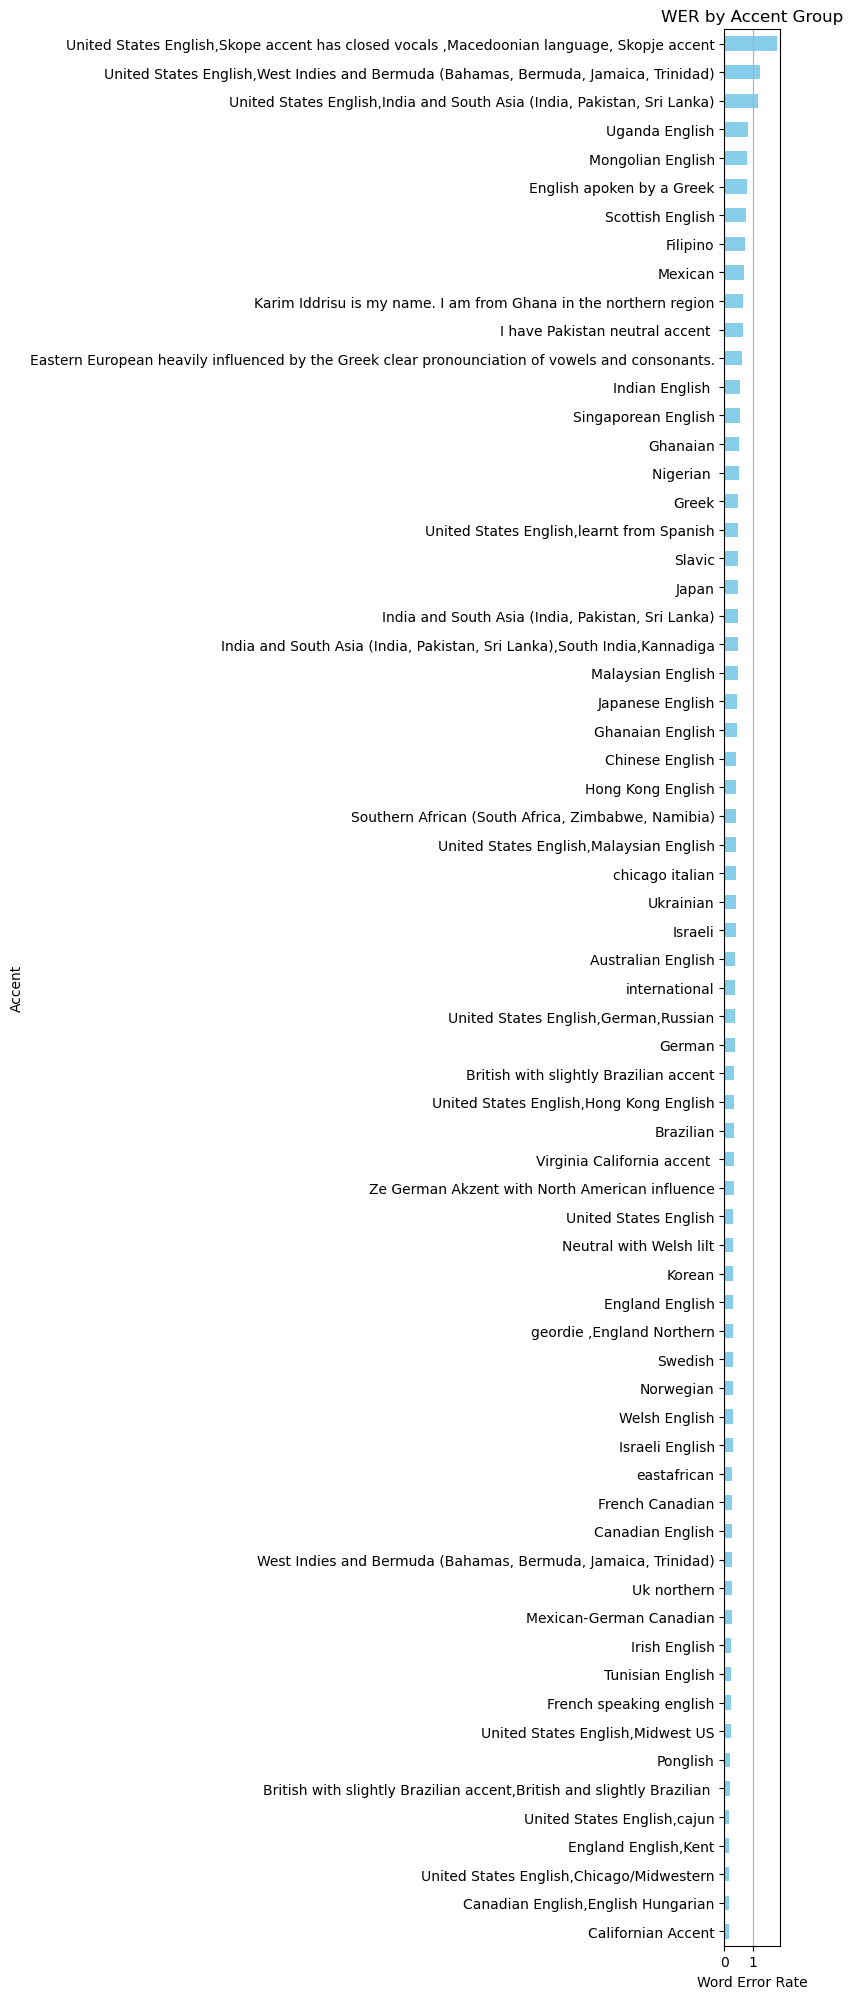

In [17]:
group_wers.sort_values().plot(
    kind='barh',
    color='skyblue',
    figsize=(8, max(4, len(group_wers) * 0.3))
)

plt.title("WER by Accent Group")
plt.xlabel("Word Error Rate")
plt.ylabel("Accent")
plt.grid(axis='x')
plt.tight_layout()
plt.show()

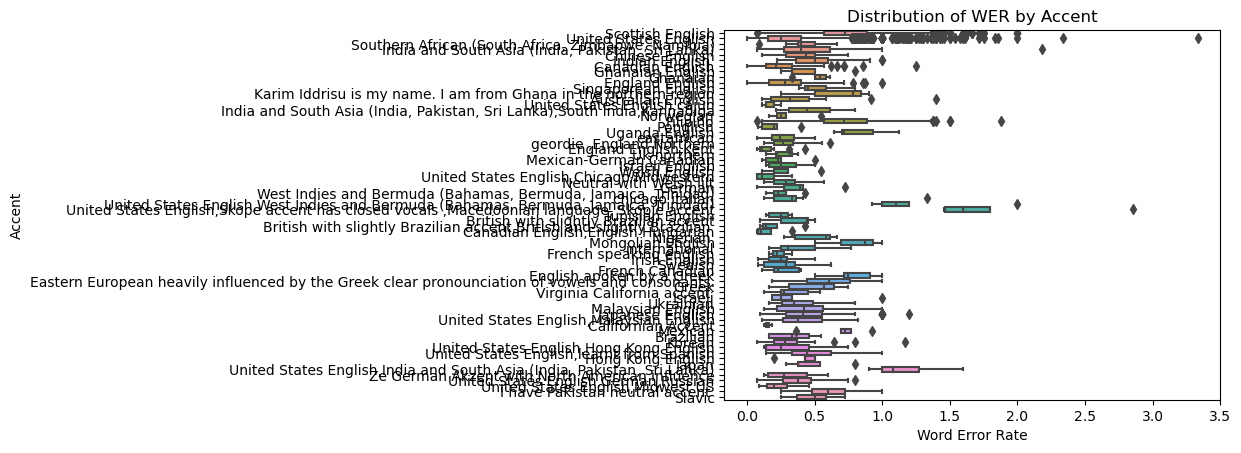

In [18]:
import seaborn as sns

sns.boxplot(x="wer", y="accent", data=merged_df, orient="h")
plt.title("Distribution of WER by Accent")
plt.xlabel("Word Error Rate")
plt.ylabel("Accent")
plt.tight_layout()
plt.show()

In [19]:
top_unfair = group_wers.sort_values(ascending=False).head(10)
print("🎯 Top 10 Accents with Highest WER:\n")
print(top_unfair.to_string())

🎯 Top 10 Accents with Highest WER:

accent
United States English,Skope accent has closed vocals ,Macedoonian language, Skopje accent    1.834645
United States English,West Indies and Bermuda (Bahamas, Bermuda, Jamaica, Trinidad)          1.244615
United States English,India and South Asia (India, Pakistan, Sri Lanka)                      1.169930
Uganda English                                                                               0.822143
Mongolian English                                                                            0.799176
English apoken by a Greek                                                                    0.774675
Scottish English                                                                             0.740588
Filipino                                                                                     0.723143
Mexican                                                                                      0.695105
Karim Iddrisu is my name. I am from Gha

In [20]:
import numpy as np

mean_wer = group_wers.mean()
std_wer = group_wers.std()
max_diff = group_wers.max() - group_wers.min()
cv = std_wer / mean_wer

print(f"📊 Average WER: {mean_wer:.3f}")
print(f"📉 Std Dev of WERs: {std_wer:.3f}")
print(f"⚖️ Max Disparity (Worst - Best): {max_diff:.3f}")
print(f"🔁 Coefficient of Variation: {cv:.3f}")

📊 Average WER: 0.439
📉 Std Dev of WERs: 0.276
⚖️ Max Disparity (Worst - Best): 1.684
🔁 Coefficient of Variation: 0.629
